In [1]:
# ============================================================
# Bay Area Housing Affordability Analysis (2019–2023)
# Author: Tannaz Haghi
# Data Sources: U.S. Census Bureau ACS 5-Year Estimates
# ============================================================

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

/Users/tannazhaghi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Census API Key
CENSUS_KEY = "8534f8b1761cffd2000f70d777dc98d76fdacecd"  # Replace with your key

# Bay Area county FIPS codes
# Format: (state_fips, county_fips, county_name)
counties = {
    "06001": "Alameda",
    "06013": "Contra Costa",
    "06041": "Marin",
    "06055": "Napa",
    "06075": "San Francisco",
    "06081": "San Mateo",
    "06085": "Santa Clara",
    "06097": "Sonoma",
    "06095": "Solano",
}

# Years to analyze
years = [2019, 2020, 2021, 2022, 2023]

print(f"Analyzing {len(counties)} counties across {len(years)} years")

Analyzing 9 counties across 5 years


In [3]:
def fetch_census_data(year, key):
    url = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": "NAME,B19013_001E,B25064_001E",
        "for": "county:*",
        "in": "state:06",
        "key": key
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    # First row is headers
    headers = data[0]
    rows = data[1:]
    
    df = pd.DataFrame(rows, columns=headers)
    df["year"] = year
    return df

# Fetch all years and combine
frames = []
for year in years:
    df = fetch_census_data(year, CENSUS_KEY)
    frames.append(df)
    print(f"Fetched {year}: {len(df)} counties")

raw_df = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows fetched: {len(raw_df)}")
raw_df.head()

Fetched 2019: 58 counties
Fetched 2020: 58 counties
Fetched 2021: 58 counties
Fetched 2022: 58 counties
Fetched 2023: 58 counties

Total rows fetched: 290


,NAME,B19013_001E,B25064_001E,state,county,year
0,"Merced County, California",53672,1021,06,047,2019
1,"Mariposa County, California",48820,929,06,043,2019
2,"Modoc County, California",45507,717,06,049,2019
3,"Contra Costa County, California",99716,1819,06,013,2019
4,"Inyo County, California",57316,919,06,027,2019


In [4]:
# Filter to Bay Area counties only
bay_area_fips = list(counties.keys())
bay_area_fips_short = [f[-3:] for f in bay_area_fips]

df = raw_df[raw_df["county"].isin(bay_area_fips_short)].copy()

# Convert to numeric
df["median_income"] = pd.to_numeric(df["B19013_001E"], errors="coerce")
df["median_rent"] = pd.to_numeric(df["B25064_001E"], errors="coerce")
df["year"] = df["year"].astype(int)

# Clean county name (remove ", California")
df["county_name"] = df["NAME"].str.replace(" County, California", "", regex=False)

# Calculate rent burden (annual rent as % of annual income)
df["rent_burden"] = (df["median_rent"] * 12) / df["median_income"] * 100

# Keep only needed columns
df = df[["year", "county_name", "median_income", "median_rent", "rent_burden"]]

# Drop any nulls
df = df.dropna()

print(f"Rows after filtering: {len(df)}")
print(f"Counties: {sorted(df['county_name'].unique())}")
df.head(10)

Rows after filtering: 45
Counties: ['Alameda', 'Contra Costa', 'Marin', 'Napa', 'San Francisco', 'San Mateo', 'Santa Clara', 'Solano', 'Sonoma']


,year,county_name,median_income,median_rent,rent_burden
3,2019,Contra Costa,99716,1819,21.89
13,2019,San Francisco,112449,1895,20.22
23,2019,Marin,115246,2069,21.54
26,2019,Solano,81472,1592,23.45
39,2019,San Mateo,122641,2316,22.66
46,2019,Sonoma,81018,1621,24.01
48,2019,Alameda,99406,1797,21.69
49,2019,Napa,88596,1700,23.03
55,2019,Santa Clara,124055,2268,21.94
58,2020,Alameda,104888,1904,21.78


In [5]:
print(f"Total rows: {len(df)}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"Counties: {len(df['county_name'].unique())}")

# Save cleaned data
df.to_csv("data/bay_area_housing_clean.csv", index=False)
print("\nData saved to data/bay_area_housing_clean.csv ✓")

Total rows: 45
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Counties: 9

Data saved to data/bay_area_housing_clean.csv ✓


In [6]:
print(df['county_name'].value_counts())

county_name
Contra Costa     5
San Francisco    5
Marin            5
Solano           5
San Mateo        5
Sonoma           5
Alameda          5
Napa             5
Santa Clara      5
Name: count, dtype: int64


In [7]:
# Save to SQLite database
conn = sqlite3.connect("bay_area_housing.db")
df.to_sql("housing", conn, if_exists="replace", index=False)
print("Data saved to bay_area_housing.db ✓")

Data saved to bay_area_housing.db ✓


In [8]:
# SQL Query 1: Rank counties by rent burden in 2023
q1 = """
    SELECT
        county_name,
        ROUND(median_income, 0) AS median_income,
        ROUND(median_rent, 0) AS median_rent,
        ROUND(rent_burden, 1) AS rent_burden_pct,
        RANK() OVER (ORDER BY rent_burden DESC) AS affordability_rank
    FROM housing
    WHERE year = 2023
    ORDER BY rent_burden DESC
"""

q1_result = pd.read_sql(q1, conn)
q1_result

,county_name,median_income,median_rent,rent_burden_pct,affordability_rank
0,Solano,99994.00,2088.00,25.10,1
1,Sonoma,102840.00,2093.00,24.40,2
2,Napa,108970.00,2141.00,23.60,3
3,San Mateo,156000.00,2893.00,22.30,4
4,Contra Costa,125727.00,2322.00,22.20,5
5,Alameda,126240.00,2318.00,22.00,6
6,Marin,142785.00,2584.00,21.70,7
7,Santa Clara,159674.00,2814.00,21.10,8
8,San Francisco,141446.00,2419.00,20.50,9


In [9]:
# SQL Query 2: Year-over-year change in rent burden using LAG
q2 = """
    SELECT
        county_name,
        year,
        ROUND(rent_burden, 1) AS rent_burden_pct,
        ROUND(rent_burden - LAG(rent_burden) 
            OVER (PARTITION BY county_name ORDER BY year), 2) AS yoy_change
    FROM housing
    ORDER BY county_name, year
"""

q2_result = pd.read_sql(q2, conn)
q2_result

,county_name,year,rent_burden_pct,yoy_change
0,Alameda,2019,21.70,NaN
1,Alameda,2020,21.80,0.09
2,Alameda,2021,21.90,0.10
3,Alameda,2022,21.80,-0.05
4,Alameda,2023,22.00,0.20
5,Contra Costa,2019,21.90,NaN
6,Contra Costa,2020,22.20,0.36
7,Contra Costa,2021,22.40,0.14
8,Contra Costa,2022,22.30,-0.05
9,Contra Costa,2023,22.20,-0.17


In [10]:
# SQL Query 3: Counties above/below 30% HUD affordability threshold
q3 = """
    SELECT
        county_name,
        year,
        ROUND(rent_burden, 1) AS rent_burden_pct,
        CASE
            WHEN rent_burden >= 30 THEN 'Cost Burdened'
            WHEN rent_burden >= 25 THEN 'At Risk'
            ELSE 'Affordable'
        END AS affordability_status
    FROM housing
    ORDER BY year, rent_burden DESC
"""

q3_result = pd.read_sql(q3, conn)
q3_result

,county_name,year,rent_burden_pct,affordability_status
0,Sonoma,2019,24.00,Affordable
1,Solano,2019,23.40,Affordable
2,Napa,2019,23.00,Affordable
3,San Mateo,2019,22.70,Affordable
4,Santa Clara,2019,21.90,Affordable
5,Contra Costa,2019,21.90,Affordable
6,Alameda,2019,21.70,Affordable
7,Marin,2019,21.50,Affordable
8,San Francisco,2019,20.20,Affordable
9,Sonoma,2020,24.30,Affordable


In [11]:
# By Census median measures, most Bay Area counties appear affordable. But when we compare against actual market-rate rents from Zillow, a dramatically different picture emerges — one where new renters across all Bay Area counties face severe cost burden.

In [12]:
# Load Zillow rent data
zillow_raw = pd.read_csv("data/zillow_rent.csv")
print(f"Shape: {zillow_raw.shape}")
print(f"Columns: {zillow_raw.columns.tolist()[:10]}")
zillow_raw.head()

Shape: (1362, 146)
Columns: ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS', '2015-01-31']


,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,2015-06-30,2015-07-31,2015-08-31,2015-09-30,2015-10-31,2015-11-30,2015-12-31,2016-01-31,2016-02-29,2016-03-31,2016-04-30,2016-05-31,2016-06-30,2016-07-31,2016-08-31,2016-09-30,2016-10-31,2016-11-30,2016-12-31,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,2018-06-30,2018-07-31,2018-08-31,2018-09-30,2018-10-31,2018-11-30,2018-12-31,2019-01-31,2019-02-28,2019-03-31,2019-04-30,2019-05-31,2019-06-30,2019-07-31,2019-08-31,2019-09-30,2019-10-31,2019-11-30,2019-12-31,2020-01-31,2020-02-29,2020-03-31,2020-04-30,2020-05-31,2020-06-30,2020-07-31,2020-08-31,2020-09-30,2020-10-31,2020-11-30,2020-12-31,2021-01-31,2021-02-28,2021-03-31,2021-04-30,2021-05-31,2021-06-30,2021-07-31,2021-08-31,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30,2022-10-31,2022-11-30,2022-12-31,2023-01-31,2023-02-28,2023-03-31,2023-04-30,2023-05-31,2023-06-30,2023-07-31,2023-08-31,2023-09-30,2023-10-31,2023-11-30,2023-12-31,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,1684.46,1696.80,1713.13,1727.56,1743.51,1753.68,1767.40,1776.75,1789.98,1794.55,1801.27,1808.14,1819.62,1830.81,1844.14,1855.44,1869.15,1879.06,1891.86,1898.75,1904.96,1906.69,1907.69,1911.89,1926.85,1943.76,1965.10,1976.54,1992.03,2000.46,2012.24,2017.54,2023.33,2024.21,2028.22,2033.66,2044.51,2059.03,2069.10,2078.66,2086.43,2099.64,2111.97,2122.33,2126.54,2129.66,2134.56,2140.18,2145.51,2149.23,2162.13,2174.74,2188.29,2197.21,2204.86,2210.21,2213.44,2214.62,2216.20,2218.94,2225.10,2229.53,2230.08,2222.80,2216.66,2213.75,2215.18,2213.65,2208.09,2203.11,2201.21,2199.41,2206.18,2213.27,2224.30,2233.18,2249.44,2278.65,2314.51,2354.68,2385.05,2405.75,2417.55,2434.20,2452.79,2477.88,2500.06,2526.11,2547.06,2567.32,2586.53,2602.50,2612.56,2610.42,2606.43,2601.79,2603.62,2610.61,2625.17,2635.00,2643.17,2646.03,2652.39,2657.92,2658.85,2655.95,2647.26,2642.05,2645.37,2654.32,2667.57,2678.13,2689.13,2698.27,2707.71,2712.90,2718.17,2715.69,2712.61,2706.58,2728.35,2750.49,2772.44,2768.58,2770.32,2773.37,2778.67,2780.79,2782.54,2780.38,2773.41,2763.25,2764.80,2771.11,2783.50,2792.33,2800.40
1,139,1,Cook County,county,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",17,31,1468.21,1477.88,1489.37,1499.26,1510.17,1520.95,1526.52,1529.58,1523.95,1515.59,1505.63,1504.93,1514.66,1527.77,1540.87,1549.15,1557.54,1566.29,1573.25,1578.07,1570.93,1559.72,1544.74,1537.83,1544.06,1560.39,1580.97,1595.69,1607.41,1614.07,1615.85,1610.81,1603.28,1589.89,1579.69,1576.97,1586.73,1602.00,1615.31,1626.64,1637.31,1647.86,1653.60,1650.24,1636.43,1622.16,1613.10,1614.20,1623.80,1635.96,1653.97,1668.93,1682.60,1690.05,1692.93,1693.17,1687.48,1679.64,1670.04,1664.06,1673.36,1686.45,1702.53,1703.75,1702.57,1699.42,1697.30,1688.33,1668.77,1641.42,1618.52,1610.28,1613.50,1627.38,1645.97,1674.15,1702.65,1728.68,1746.71,1757.54,1762.22,1760.23,1759.09,1764.37,1779.08,1797.07,1819.36,1844.49,1871.44,1892.34,1908.12,1915.37,1914.79,1909.28,1904.14,1905.87,1915.27,1930.91,1949.78,1969.34,1991.47,2009.85,2021.85,2027.57,2022.07,2011.33,2001.84,2003.77,2015.11,2032.10,2049.32,2070.19,2087.63,2103.74,2111.11,2112.63,2109.10,2105.54,2104.12,2106.51,2117.45,2136.57,2160.71,2184.66,2206.83,2226.98,2238.69,2243.42,2241.47,2234.15,2228.42,2225.30,2240.06,2261.62,2289.28,2311.93,2334.40
2,1090,2,Harris County,county,TX,TX,"Houston-Th

In [13]:
# Filter to Bay Area California counties
bay_area_names = [
    "Alameda County", "Contra Costa County", "Marin County",
    "Napa County", "San Francisco County", "San Mateo County",
    "Santa Clara County", "Sonoma County", "Solano County"
]

zillow_bay = zillow_raw[
    (zillow_raw["StateName"] == "CA") & 
    (zillow_raw["RegionName"].isin(bay_area_names))
].copy()

print(f"Bay Area counties found: {len(zillow_bay)}")
print(zillow_bay["RegionName"].tolist())

Bay Area counties found: 9
['Santa Clara County', 'Alameda County', 'Contra Costa County', 'San Francisco County', 'San Mateo County', 'Sonoma County', 'Solano County', 'Marin County', 'Napa County']


In [14]:
# Reshape from wide to long format
date_cols = [col for col in zillow_bay.columns if col.startswith("20")]

zillow_long = zillow_bay.melt(
    id_vars=["RegionName"],
    value_vars=date_cols,
    var_name="date",
    value_name="market_rent"
)

# Convert date and extract year
zillow_long["date"] = pd.to_datetime(zillow_long["date"])
zillow_long["year"] = zillow_long["date"].dt.year

# Clean county name to match Census data
zillow_long["county_name"] = zillow_long["RegionName"].str.replace(" County", "", regex=False)

# Filter to 2019-2023 and calculate annual average market rent
zillow_annual = zillow_long[zillow_long["year"].isin(years)].groupby(
    ["county_name", "year"]
)["market_rent"].mean().reset_index()

zillow_annual["market_rent"] = zillow_annual["market_rent"].round(0)

print(f"Rows: {len(zillow_annual)}")
zillow_annual.head(10)

Rows: 45


,county_name,year,market_rent
0,Alameda,2019,2535.00
1,Alameda,2020,2533.00
2,Alameda,2021,2532.00
3,Alameda,2022,2680.00
4,Alameda,2023,2693.00
5,Contra Costa,2019,2275.00
6,Contra Costa,2020,2327.00
7,Contra Costa,2021,2435.00
8,Contra Costa,2022,2585.00
9,Contra Costa,2023,2613.00


In [15]:
# Merge Census and Zillow data
combined = df.merge(zillow_annual, on=["county_name", "year"], how="inner")

# Calculate market-rate rent burden using Zillow rent + Census income
combined["market_rent_burden"] = (combined["market_rent"] * 12) / combined["median_income"] * 100
combined["market_rent_burden"] = combined["market_rent_burden"].round(1)

# Rename for clarity
combined = combined.rename(columns={"rent_burden": "census_rent_burden"})

print(f"Rows: {len(combined)}")
print(f"Counties: {combined['county_name'].nunique()}")
combined[["year", "county_name", "median_income", "median_rent", 
          "census_rent_burden", "market_rent", "market_rent_burden"]].head(10)

Rows: 45
Counties: 9


,year,county_name,median_income,median_rent,census_rent_burden,market_rent,market_rent_burden
0,2019,Contra Costa,99716,1819,21.89,2275.00,27.40
1,2019,San Francisco,112449,1895,20.22,3519.00,37.60
2,2019,Marin,115246,2069,21.54,2892.00,30.10
3,2019,Solano,81472,1592,23.45,1870.00,27.50
4,2019,San Mateo,122641,2316,22.66,3136.00,30.70
5,2019,Sonoma,81018,1621,24.01,2073.00,30.70
6,2019,Alameda,99406,1797,21.69,2535.00,30.60
7,2019,Napa,88596,1700,23.03,2209.00,29.90
8,2019,Santa Clara,124055,2268,21.94,3010.00,29.10
9,2020,Alameda,104888,1904,21.78,2533.00,29.00


In [16]:
# Save combined data to SQLite
combined.to_sql("housing_combined", conn, if_exists="replace", index=False)
print("Combined data saved ✓")

# SQL Query 4: Census vs Market rent burden comparison in 2023
q4 = """
    SELECT
        county_name,
        ROUND(census_rent_burden, 1) AS census_burden_pct,
        ROUND(market_rent_burden, 1) AS market_burden_pct,
        ROUND(market_rent_burden - census_rent_burden, 1) AS gap,
        CASE
            WHEN market_rent_burden >= 30 THEN 'Cost Burdened'
            WHEN market_rent_burden >= 25 THEN 'At Risk'
            ELSE 'Affordable'
        END AS true_affordability_status
    FROM housing_combined
    WHERE year = 2023
    ORDER BY market_rent_burden DESC
"""

q4_result = pd.read_sql(q4, conn)
q4_result

Combined data saved ✓


,county_name,census_burden_pct,market_burden_pct,gap,true_affordability_status
0,Napa,23.60,29.70,6.10,At Risk
1,Sonoma,24.40,28.80,4.40,At Risk
2,San Francisco,20.50,28.40,7.90,At Risk
3,Marin,21.70,28.00,6.30,At Risk
4,Solano,25.10,27.10,2.00,At Risk
5,Alameda,22.00,25.60,3.60,At Risk
6,San Mateo,22.30,25.00,2.70,At Risk
7,Contra Costa,22.20,24.90,2.70,Affordable
8,Santa Clara,21.10,24.30,3.20,Affordable


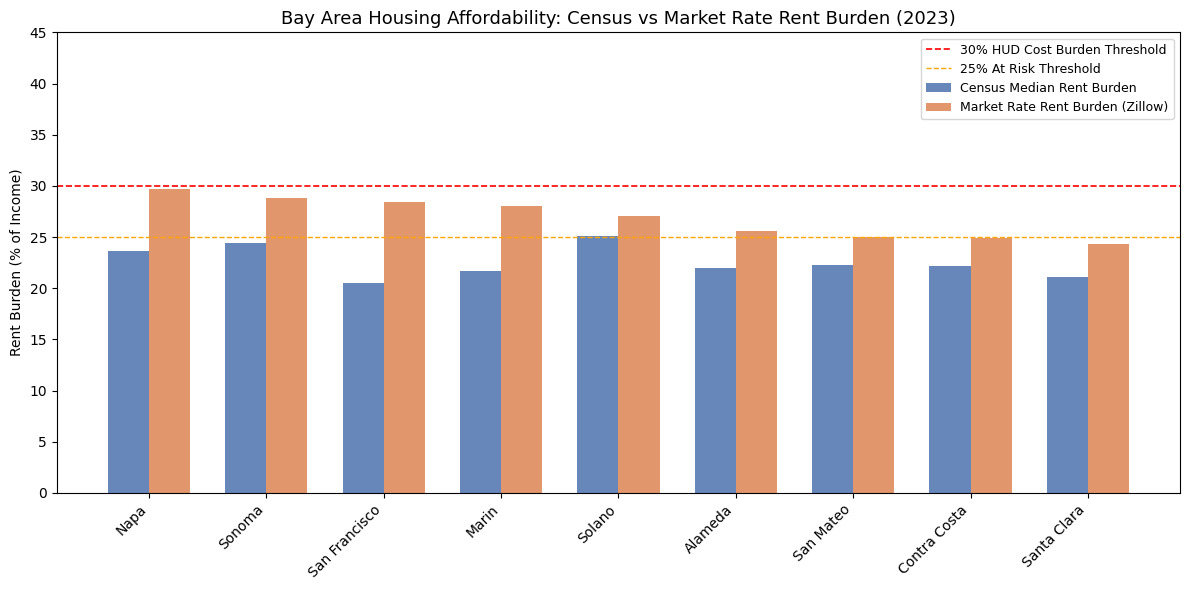

In [17]:
# Visualization 1: Census vs Market Rent Burden by County (2023)
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(q4_result))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], q4_result["census_burden_pct"], 
               width, label="Census Median Rent Burden", color="#4C72B0", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], q4_result["market_rent_burden_pct"] 
               if "market_rent_burden_pct" in q4_result.columns 
               else q4_result["market_burden_pct"], 
               width, label="Market Rate Rent Burden (Zillow)", color="#DD8452", alpha=0.85)

ax.axhline(30, color="red", linestyle="--", linewidth=1.2, label="30% HUD Cost Burden Threshold")
ax.axhline(25, color="orange", linestyle="--", linewidth=1.0, label="25% At Risk Threshold")

ax.set_xticks(list(x))
ax.set_xticklabels(q4_result["county_name"], rotation=45, ha="right")
ax.set_title("Bay Area Housing Affordability: Census vs Market Rate Rent Burden (2023)", fontsize=13)
ax.set_ylabel("Rent Burden (% of Income)")
ax.set_ylim(0, 45)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("charts/census_vs_market_burden.png", dpi=150)
plt.show()

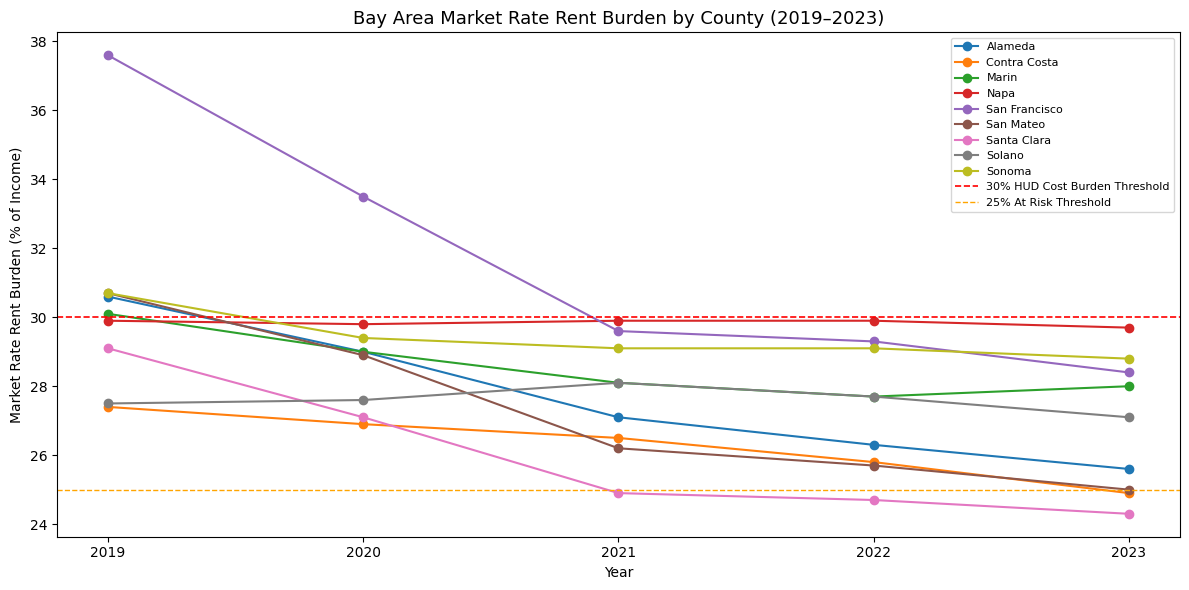

In [19]:
# Visualization 2: Market rent burden trend over time by county
fig, ax = plt.subplots(figsize=(12, 6))

for county, group in combined.groupby("county_name"):
    group_sorted = group.sort_values("year")
    ax.plot(group_sorted["year"], group_sorted["market_rent_burden"], 
            marker="o", label=county)

ax.axhline(30, color="red", linestyle="--", linewidth=1.2, 
           label="30% HUD Cost Burden Threshold")
ax.axhline(25, color="orange", linestyle="--", linewidth=1.0,
           label="25% At Risk Threshold")

ax.set_title("Bay Area Market Rate Rent Burden by County (2019–2023)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Market Rate Rent Burden (% of Income)")
ax.set_xticks(years)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("charts/rent_burden_trends.png", dpi=150)
plt.show()

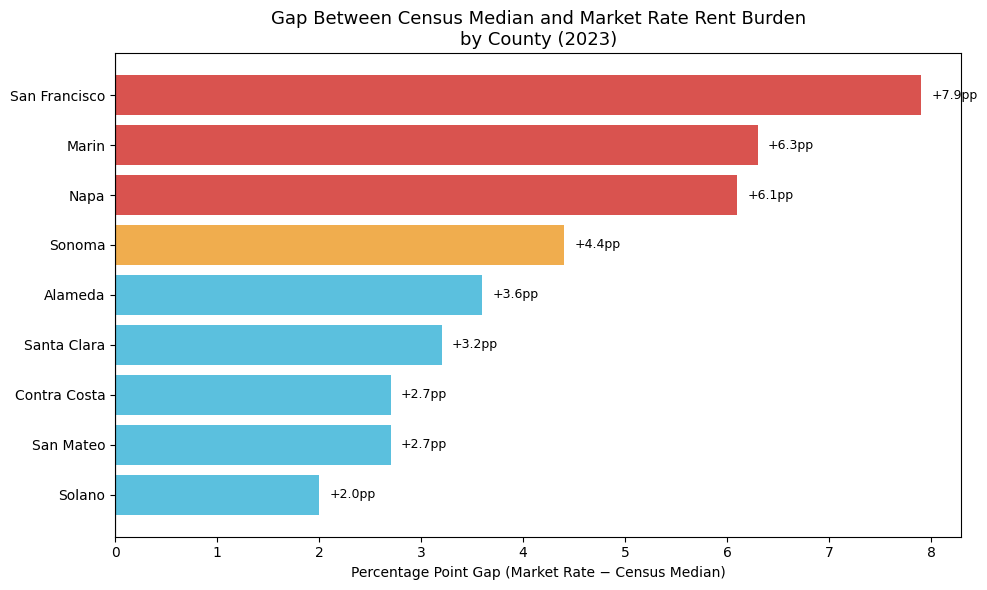

In [20]:
# Visualization 3: Gap between Census and Market rent burden by county (2023)
fig, ax = plt.subplots(figsize=(10, 6))

q4_sorted = q4_result.sort_values("gap", ascending=True)

colors = ["#d9534f" if x >= 6 else "#f0ad4e" if x >= 4 else "#5bc0de" 
          for x in q4_sorted["gap"]]

ax.barh(q4_sorted["county_name"], q4_sorted["gap"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Gap Between Census Median and Market Rate Rent Burden\nby County (2023)", 
             fontsize=13)
ax.set_xlabel("Percentage Point Gap (Market Rate − Census Median)")

# Add value labels
for i, (val, name) in enumerate(zip(q4_sorted["gap"], q4_sorted["county_name"])):
    ax.text(val + 0.1, i, f"+{val}pp", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("charts/rent_burden_gap.png", dpi=150)
plt.show()

## Key Findings

1. **Census data systematically understates rent burden** — across all 9 Bay 
   Area counties, market-rate rent burden (Zillow) exceeds Census median rent 
   burden by 2–8 percentage points, with San Francisco showing the largest 
   gap (+7.9pp).

2. **San Francisco had the most dramatic improvement** — market-rate rent 
   burden dropped from 37.6% in 2019 to 28.4% in 2023, reflecting COVID-era 
   population outflows that temporarily reduced rental demand.

3. **Napa and Sonoma face the most persistent burden** — both counties 
   remained near or above the 30% HUD cost burden threshold throughout 
   2019–2023, driven by lower incomes relative to rising rents.

4. **Santa Clara improved the most** — tech salary growth significantly 
   outpaced rent increases, dropping market-rate burden from 29.1% to 24.3%.

5. **Solano is the hidden affordability crisis** — despite having the lowest 
   rents in the region, its lower income base keeps rent burden the highest 
   among Bay Area counties by Census measures (25.1% in 2023).

## Limitations

1. **ACS 5-year estimates are rolling averages** — the "2023" ACS data 
   reflects 2019–2023 conditions, smoothing out single-year fluctuations.

2. **Census median rent includes long-term renters** — protected tenants 
   paying below-market rents pull the median down, understating the true 
   burden on new market-rate renters.

3. **Zillow ZORI reflects asking rents** — actual signed lease prices may 
   differ, and ZORI coverage varies by county size.

4. **Income data does not account for household composition** — a family 
   of four earning $125K faces very different affordability than a single 
   earner at the same income.

5. **Analysis covers renters only** — homeowners with fixed mortgages 
   are excluded, which would show a different affordability picture.